In [1]:
import sys
import torch
import matplotlib.pyplot as plt

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

LATENT_DIM = 512
TRUNCATION_PSI = 0.8

STYLEGAN_PKL = (
    "../stylegan_cats/outputs_cats/"
    "network-snapshot-001000.pkl"
)

print("Device:", DEVICE)

Device: cuda


In [2]:
sys.path.append("../stylegan2-ada-pytorch")
import legacy

print("Loading StyleGAN2...")

with open(STYLEGAN_PKL, "rb") as f:
    network = legacy.load_network_pkl(f)

G = network["G_ema"].to(DEVICE)
G.eval()

print("StyleGAN loaded")

Loading StyleGAN2...
StyleGAN loaded


In [3]:
def latent_from_seed(seed):
    g = torch.Generator(device=DEVICE)
    g.manual_seed(int(seed))

    return torch.randn(
        1,
        LATENT_DIM,
        generator=g,
        device=DEVICE
    )

In [4]:
def generate_image(z):
    with torch.no_grad():
        c = (
            torch.zeros(
                z.shape[0],
                G.c_dim,
                device=DEVICE
            )
            if G.c_dim > 0 else None
        )

        img = G(
            z,
            c,
            truncation_psi=TRUNCATION_PSI
        )

        img = (img * 0.5 + 0.5).clamp(0, 1)

    return img

In [5]:
POSITIVE_SEEDS = [
    21, 21, 40, 42, 52, 99, 9, 110, 161, 182, 189, 284, 409, 510, 550, 596, 755, 785, 827, 819, 900, 927
]

NEGATIVE_SEEDS = [
    15, 30, 45, 63, 71, 49, 57, 183, 204, 237, 209, 332, 387, 488, 486, 545, 570, 601, 655, 804, 824, 894
]

In [6]:
pos_z = torch.cat(
    [latent_from_seed(s) for s in POSITIVE_SEEDS],
    dim=0
)

neg_z = torch.cat(
    [latent_from_seed(s) for s in NEGATIVE_SEEDS],
    dim=0
)

d_X = (
        pos_z.mean(dim=0, keepdim=True)
        - neg_z.mean(dim=0, keepdim=True)
)

print("Direction computed:", d_X.shape)

Direction computed: torch.Size([1, 512])


In [10]:
NEUTRAL_SEEDS = [
    19, 423, 540, 207
]

In [11]:
alphas = [-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2]

all_results = []

with torch.no_grad():
    for seed in NEUTRAL_SEEDS:

        z0 = latent_from_seed(seed)

        row_imgs = []

        for alpha in alphas:
            z = z0 + alpha * d_X

            img = generate_image(z)

            row_imgs.append(img)

        row_imgs = torch.cat(row_imgs, dim=0)
        all_results.append((seed, row_imgs))

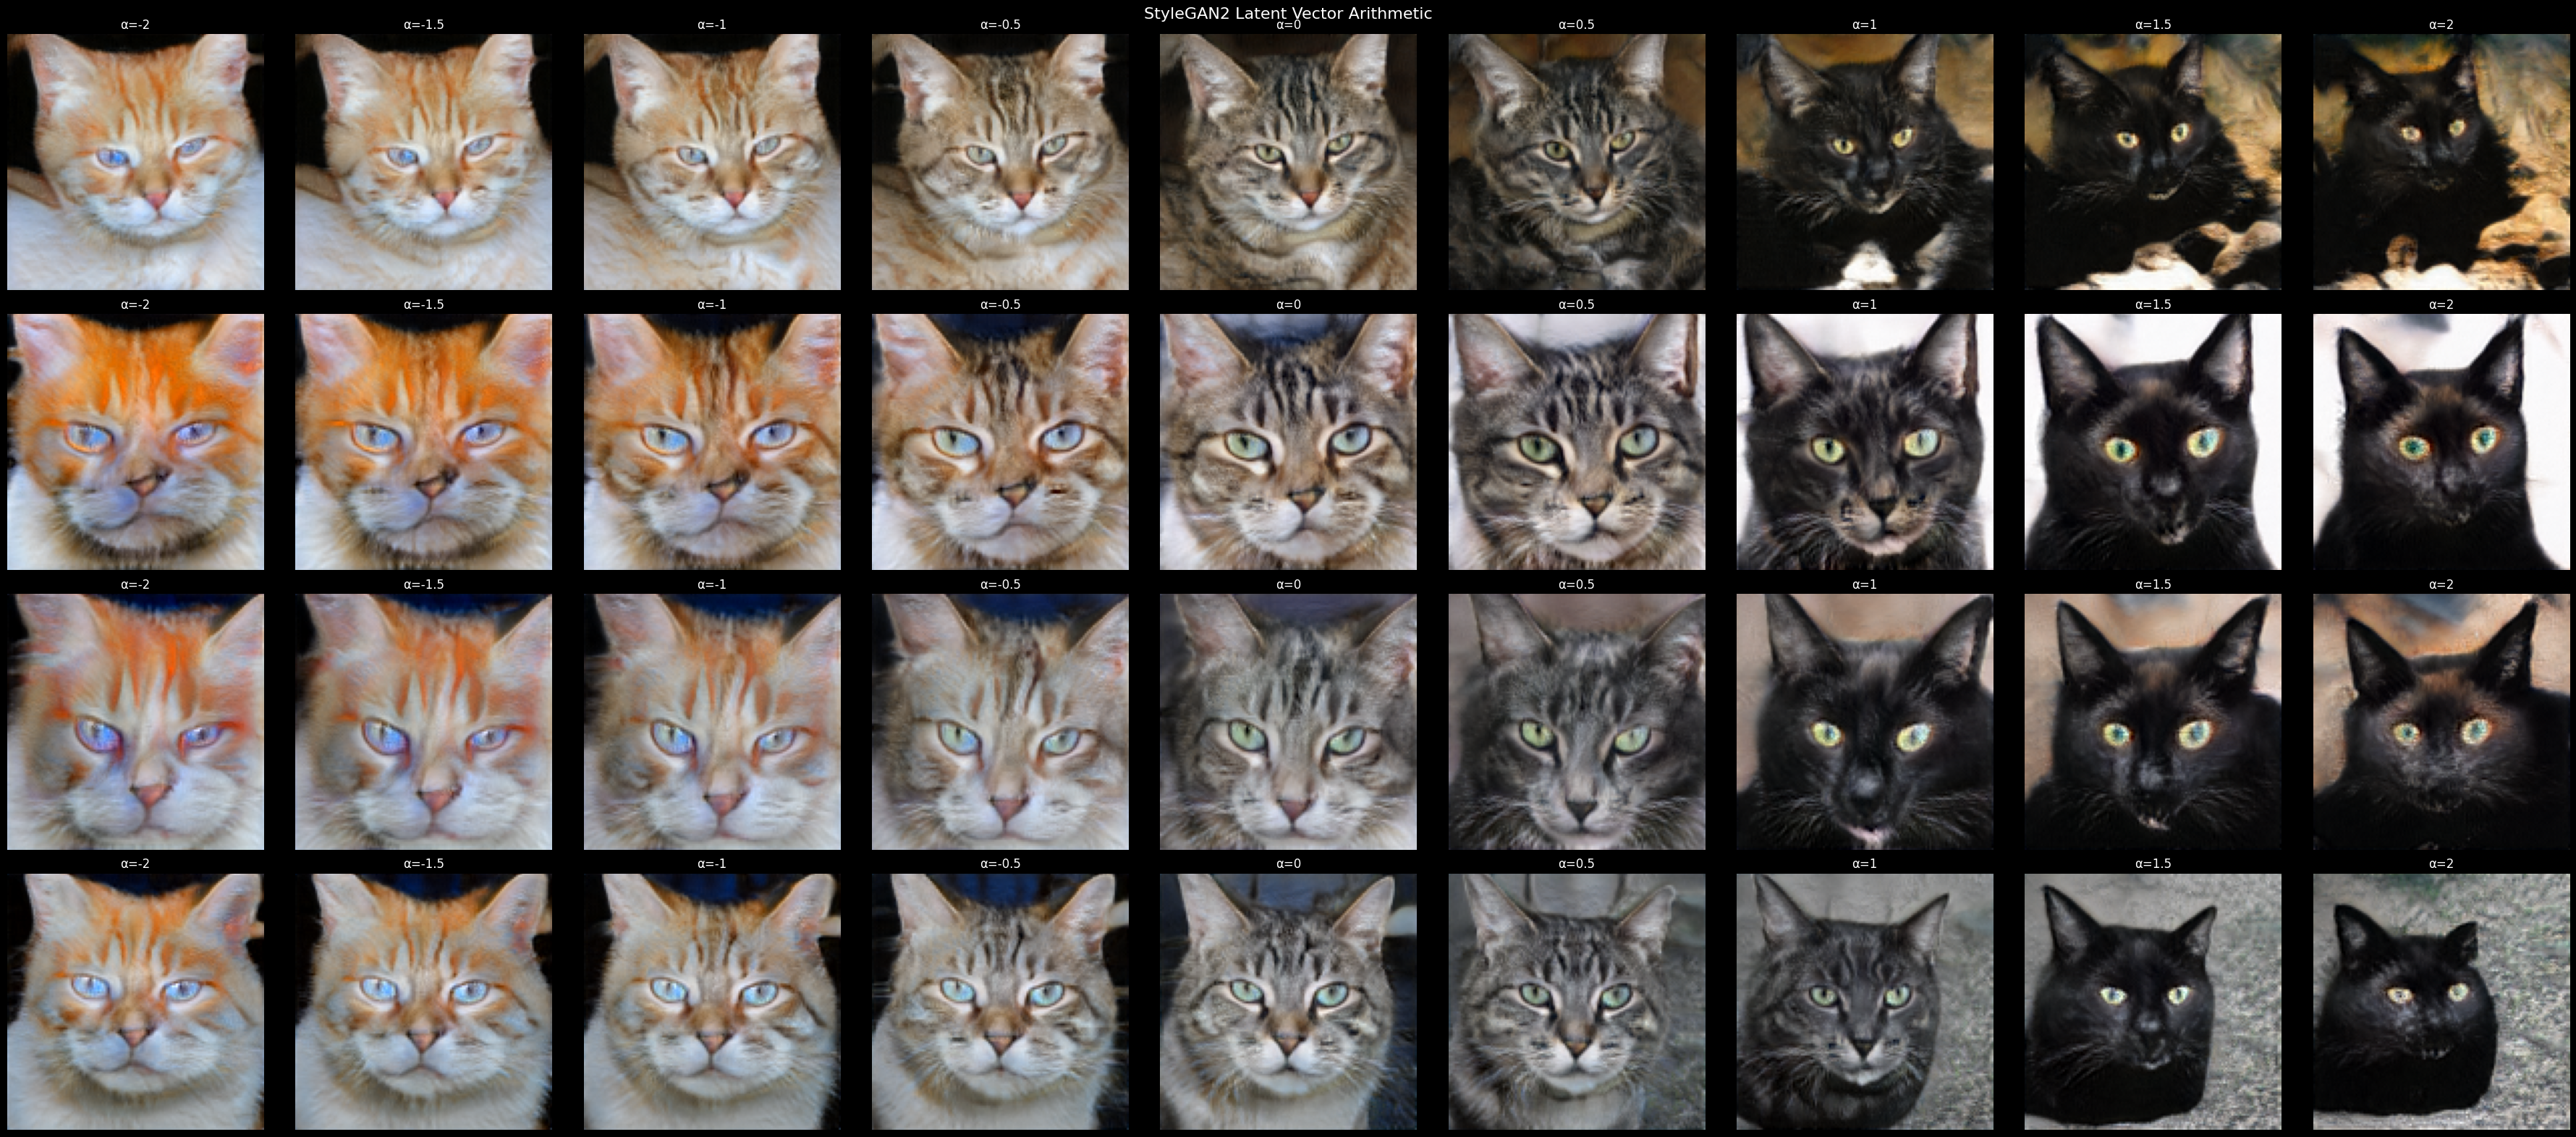

In [12]:
n_rows = len(NEUTRAL_SEEDS)
n_cols = len(alphas)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 4 * n_rows)
)

if n_rows == 1:
    axes = axes[None, :]

for r, (seed, imgs) in enumerate(all_results):

    for c, alpha in enumerate(alphas):
        img = imgs[c].cpu().permute(1, 2, 0)

        axes[r, c].imshow(img)
        axes[r, c].axis("off")

        axes[r, c].set_title(f"α={alpha}")

    axes[r, 0].set_ylabel(
        f"seed {seed}",
        fontsize=12
    )

plt.suptitle(
    "StyleGAN2 Latent Vector Arithmetic",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "stylegan_latent_arithmetic.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()